<a href="https://colab.research.google.com/github/giovaferrarigf-design/Machine-Learning/blob/main/age_prediction_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Age prediction: data preparation and explanatory data analysis (EDA)

Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Loading and showing input (features) and output data (desired output)

In [ ]:
df = pd.read_excel('https://raw.githubusercontent.com/sdiciotti/Age-Prediction-Demo/main/NKI2_data.xlsx')
##these are features extracted from brain MRI, many features
##in exam I already have the data,
print (type(df))

<class 'pandas.core.frame.DataFrame'>


Print the size of the dataframe

In [ ]:
df.shape

(73, 35)

Print the dataframe

In [ ]:
print(df)

    Age Sex  cortex_CT  lh_cortex_CT  rh_cortex_CT  lh_frontalGM_CT  \
0    13   F   2.563765       2.53793       2.58960            2.604   
1    13   M   2.816775       2.80403       2.82952            2.870   
2    16   F   2.590785       2.60300       2.57857            2.659   
3    17   M   2.618340       2.62847       2.60821            2.780   
4    17   M   2.737575       2.77298       2.70217            2.866   
..  ...  ..        ...           ...           ...              ...   
68   14   F   2.785335       2.80093       2.76974            2.956   
69   16   M   2.645850       2.62908       2.66262            2.793   
70   12   F   2.731690       2.73606       2.72732            2.854   
71   10   F   2.674965       2.67007       2.67986            2.749   
72   11   M   2.733215       2.74924       2.71719            2.846   

    lh_occipitalGM_CT  lh_temporalGM_CT  lh_parietalGM_CT  rh_frontalGM_CT  \
0               2.084             2.694             2.432            

Check the features and output variables name

In [ ]:
features = list(df.columns)
type(features)

list

In [ ]:
print(features)

['Age', 'Sex', 'cortex_CT', 'lh_cortex_CT', 'rh_cortex_CT', 'lh_frontalGM_CT', 'lh_occipitalGM_CT', 'lh_temporalGM_CT', 'lh_parietalGM_CT', 'rh_frontalGM_CT', 'rh_occipitalGM_CT', 'rh_temporalGM_CT', 'rh_parietalGM_CT', 'cortex_pial_lgi', 'lh_cortex_pial_lgi', 'rh_cortex_pial_lgi', 'lh_frontal_pial_lgi', 'lh_occipital_pial_lgi', 'lh_temporal_pial_lgi', 'lh_parietal_pial_lgi', 'rh_frontal_pial_lgi', 'rh_occipital_pial_lgi', 'rh_temporal_pial_lgi', 'rh_parietal_pial_lgi', 'cerebralGM_FD', 'lh_cerebralGM_FD', 'lh_frontalGM_FD', 'lh_temporalGM_FD', 'lh_parietalGM_FD', 'lh_occipitalGM_FD', 'rh_cerebralGM_FD', 'rh_frontalGM_FD', 'rh_temporalGM_FD', 'rh_parietalGM_FD', 'rh_occipitalGM_FD']


Plotting some data

Text(0, 0.5, 'cortex CT (mm)')

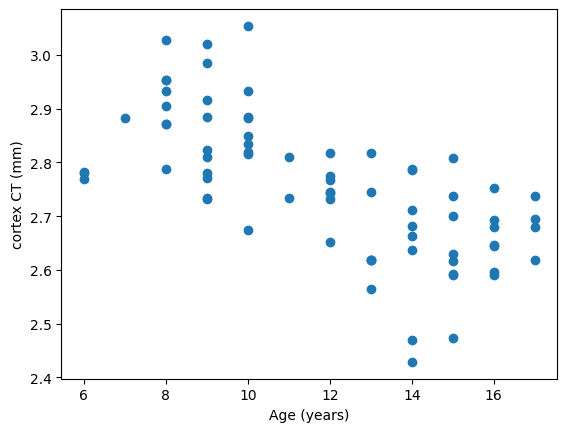

In [ ]:
plt.scatter(df['Age'],df['cortex_CT']) ##scatter plot (of matplot lib) in order to visualize x and y variable like this
plt.xlabel('Age (years)')
plt.ylabel('cortex CT (mm)')

In [ ]:
print("Dataframe shape before NaN removal:", df.shape)

Dataframe shape before NaN removal: (73, 35)


Removing missing data

In [ ]:
df.dropna(axis=0, how='any', inplace=True)
print("Dataframe shape after NaN removal:", df.shape) ## I need to handle NAN (here I remove the subject where I see this, dropping rows containing this)

Dataframe shape after NaN removal: (72, 35)


Preparing the design matrix X and the desired output y

In [ ]:
X = df.iloc[:,2::]
y = df['Age']
print (type(X))
print (type(y))
print (X.shape)
print (y.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(72, 33)
(72,)


A quick quality control

In [ ]:
X.head(6)

,cortex_CT,lh_cortex_CT,rh_cortex_CT,lh_frontalGM_CT,lh_occipitalGM_CT,lh_temporalGM_CT,lh_parietalGM_CT,rh_frontalGM_CT,rh_occipitalGM_CT,rh_temporalGM_CT,...,lh_cerebralGM_FD,lh_frontalGM_FD,lh_temporalGM_FD,lh_parietalGM_FD,lh_occipitalGM_FD,rh_cerebralGM_FD,rh_frontalGM_FD,rh_temporalGM_FD,rh_parietalGM_FD,rh_occipitalGM_FD
0,2.563765,2.53793,2.58960,2.604,2.084,2.694,2.432,2.573,2.213,2.901,...,2.4527,2.3947,2.3795,2.3840,2.2441,2.4524,2.4001,2.3942,2.3788,2.2650
1,2.816775,2.80403,2.82952,2.870,2.265,3.188,2.564,2.914,2.244,3.230,...,2.4719,2.4216,2.4228,2.3896,2.2861,2.5181,2.4290,2.4202,2.3942,2.2631
2,2.590785,2.60300,2.57857,2.659,2.058,2.877,2.537,2.649,2.083,2.787,...,2.4854,2.3733,2.3712,2.3852,2.2485,2.4820,2.3681,2.3633,2.3735,2.2511
3,2.618340,2.62847,2.60821,2.780,2.057,2.867,2.459,2.739,2.129,2.880,...,2.4911,2.4034,2.3956,2.3679,2.2631,2.4535,2.3933,2.3921,2.3683,2.2677
4,2.737575,2.77298,2.70217,2.866,2.137,3.194,2.546,2.716,2.204,3.150,...,2.5081,2.4224,2.4194,2.3738,2.2687,2.4641,2.4074,2.4158,2.3694,2.2728
5,2.752830,2.76857,2.73709,2.825,2.172,3.129,2.593,2.702,2.308,3.185,...,2.5024,2.4062,2.4273,2.3702,2.2810,2.4618,2.3929,2.4225,2.3780,2.3053


In [ ]:
print('The whole dataset contains ' + str(X.shape[0]) + ' subjects')
print('The age prediction will be performed using ' + str(X.shape[1]) + ' MRI-derived features')

The whole dataset contains 72 subjects
The age prediction will be performed using 33 MRI-derived features
